# 6.0 Finetuning
## What is finetuning?

Finetuning is the process of taking a foundational model (a model that has already been trained on a very large dataset) and training it on a smaller, more specific dataset for a specific task or domain. Rather than going through the arduous and time consuming process of training the model from scratch with your specific dataset, you can leverage the pretrained model's existing learnings of useful general representations (e.g. chemical structure, descriptors, etc.) and focus the model on your specific task.

## Why finetune?

Finetuning can be very useful, particularly when you have little or no empirical data to fully train a model. This is usually the case since empirical data is limited by resources, time, manpower, and throughput.

Consider this scenario: you have just started a new drug program and you want to use a model like ChemProp or CheMeleon to help you predict certain ADMET endpoints so you know which compounds to prioritize in assays. You start by finetuning a CheMeleon model on data curated from ChEMBL as shown in `01_Curate_ChEMBL_Data.ipynb`, since you have no empirical data of your own yet. This model gives you some predictions good enough that you're able to narrow the pool of compounds to run. Now that you have your own empirical data, you want finetune your CheMeleon model further on the specific subset of molecules that you think show the most promise for your disease target, to ideally get more accurate predictions.

## This demo

This notebook will show you how to finetune a CheMeleon model for prediction on microsomal clearance for human liver microsomes (`LOG_CLint_HLM`) on:
1. a curated ChEMBL dataset
2. ChEMBL + the train dataset from the [OpenADMET ExpansionRx Therapeutics Blind Challenge](https://openadmet.ghost.io/expansionrx-openadmet-blind-challenge/)

Model training with our ANVIL infrastructure is exactly the same as outlined in `02_Model_Training`, so we won't go into the same level of detail here. We will show how performance of finetuned model improves when predicting on the ExpansionRx test set when finetuning with ChEMBL+ExpansionRx train data vs. finetuning on ChEMBL alone. Inference is also done with ANVIL as shown in `05_Ensemble_Model_Inference`.

We have already curated a ChEMBL dataset for microsomal clearance values in `data/chembl.csv`. The raw dataset is available [here](https://github.com/OpenADMET/data-catalogs/tree/e1a9494f491339d902b3dfeaaa9ac83a3e0cf0d9/catalogs/activities/ChEMBL_Microsomal/ChEMBL35_Microsome/scaled). 

The ExpansionRx train dataset is available on our [HuggingFace](https://huggingface.co/datasets/openadmet/openadmet-expansionrx-challenge-train-data) and is downloaded as `data/exprx.csv`. 

The ExpansionRx test datset is also available on [HuggingFace](https://huggingface.co/datasets/openadmet/openadmet-expansionrx-challenge-test-data-blinded) and is downloaded as `data/exprx_test.csv`.

In [1]:
import pandas as pd

chembl = pd.read_csv("data/chembl.csv")

exprx = pd.read_csv("data/exprx.csv")

We've already done some preprocessing of both these datasets for ease of work.

In [2]:
chembl.head(10)

,OPENADMET_INCHIKEY,OPENADMET_CANONICAL_SMILES,LOG_CLint_HLM,CLint_HLM,LOG_CLint_RLM,CLint_RLM,LOG_CLint_MLM,CLint_MLM
0,MOPSJMVERRFXAX-HNNXBMFYSA-N,COCCOC1=CN=C2C=CC([C@H](C)N3N=NC4=C3C(=O)N(C3=...,2.147367,140.40,2.276462,189.00,2.583958,383.670
1,NNBYANZTLQEDDY-UHFFFAOYSA-N,CC1=NC=C(C2=NC3=C(NC4(C)CC4)N=C(NC4=CN(C5CC6(C...,1.109579,12.87,NaN,NaN,NaN,NaN
2,UAXPPQPDGOMVPD-LDFOQBSTSA-N,CCC(NC(=O)C1=CC=C(Cl)C=C1)[C@H]1[C@@H]2C[C@H](...,2.499687,316.00,2.980458,956.00,NaN,NaN
3,YTTYYCAUZAPRNY-UHFFFAOYSA-N,CC(C)S(=O)(=O)C1=CC=CC=C1NC1=NC(NC2=CC3=NNC(NC...,NaN,NaN,2.184180,152.82,NaN,NaN
4,AWLUMUGHLSXLNA-UHFFFAOYSA-N,CC1=NC(=O)C2=C(C)N=C(C3=C(C4=CC=C(C(F)(F)F)C=C...,1.204120,16.00,NaN,NaN,NaN,NaN
5,DKQOAOQZQUBSIZ-UHFFFAOYSA-N,CC(C)OC(=O)NC1CCCOC2=C(C3=CC=C(Cl)C=C3)N(C3=CC...,1.176091,15.00,NaN,NaN,NaN,NaN
6,VRXFDHAGFYWGHT-UHFFFAOYSA-N,CCNCC1=CC(NC2=CC=NC3=CC(Cl)=CC=C23)=CC=C1O,NaN,NaN,0.534026,3.42,1.634124,43.065
7,YSZNYCUUEJLLGR-UHFFFAOYSA-N,COC(=O)C1C(CN2CCC(F)(F)C2)=NC(C2=NC=CS2)=NC1(C...,NaN,NaN,NaN,NaN,1.949390,89.000
8,HAKUBDUVAGUCGC-UHFFFAOYSA-N,CCCN(CC1CC1)C1=CC(C(=O)NC2=CC=C3NN=CC3=C2)=NC=N1,1.298635,19.89,2.011147,102.60,NaN,NaN
9,IPSMAKOQUQMHED-CZIZESTLSA-N,CCOC(=O)N1CC/C(=C2/C3=CC=C(Cl)C=C3CCC3=CC=CN=C...,1.775756,59.67,NaN,NaN,NaN,NaN


In [3]:
exprx.head(10)

,OPENADMET_INCHIKEY,OPENADMET_CANONICAL_SMILES,LOG_CLint_HLM,CLint_HLM,LOG_CLint_RLM,CLint_RLM,LOG_CLint_MLM,CLint_MLM
0,XXHPNGNGSXDBMK-UHFFFAOYSA-N,CN1N=CC2=CC(C3=CC=C(OCCN4CCOCC4)C=C3)=CC=C21,1.475671,29.9,NaN,NaN,2.460296,288.6
1,SMQZYWBKOHASSN-UHFFFAOYSA-N,CN(CCOC1=CC=C(C2=CC=C3C=CN=CC3=C2)C=C1)C1CCC1,1.409933,25.7,NaN,NaN,3.361803,2300.4
2,DAXGQXFVQUYVRY-UHFFFAOYSA-N,CC1=C(N)C(C2=CC=C(OCCN3CCCC3=O)C=C2)=CC2=CN=CC...,1.385606,24.3,NaN,NaN,2.591287,390.2
3,UEZJJVAJDJNXMQ-CQSZACIVSA-N,CC1=CN(C)C(=O)C2=C1C1=CC=C(OC[C@H]3CN(C)CCO3)C...,1.369216,23.4,NaN,NaN,2.534280,342.2
4,JEUZRQMZLPUKSV-NSHDSACASA-N,C[C@H](N)COC1=CC=C2C(=C1)C1=NC3=CN=CC=C3C=C1N2C,0.949390,8.9,NaN,NaN,2.477555,300.3
5,RZMOYHIJQUQVQI-UHFFFAOYSA-N,CN1CCC(C2=CC=CC(NC3=CC=CC(C4=CC=CC(F)=C4)=N3)=...,0.908485,8.1,NaN,NaN,2.476397,299.5
6,MXTHNLAVZWLDKB-UHFFFAOYSA-N,CN1C=NC(C2=CC3=CC(C(=O)NC4CCN(C5=CC=NC=C5F)CC4...,1.587711,38.7,NaN,NaN,1.439333,27.5
7,JLZFYAJPIXDVEW-UHFFFAOYSA-N,CC1=NN=C(C2=CN=C3C(=C2)C=C(C(=O)NC2CCN(C4=CC=C...,1.509203,32.3,NaN,NaN,1.969882,93.3
8,SNZZVPGTGGBZQK-UHFFFAOYSA-N,O=C1C2=C(C=CN1CCCN1CCCCC1)C1=CC=CC(F)=C1N2,0.662758,4.6,NaN,NaN,1.984527,96.5
9,PMJZFVGMJMIKQE-UHFFFAOYSA-N,CN1C=C(C2=CN=CN=C2)C2=CC(OCC3CNC3)=CC=C21,0.740363,5.5,NaN,NaN,2.505286,320.1


We can simply concatenate these two datasets into `/data/chembl+exprx.csv`

In [4]:
combined = pd.concat([chembl, exprx])

combined.to_csv("data/chembl+exprx.csv", index=False)

We will now finetune 2 models:
1. a CheMeleon model on ChEMBL only
2. a CheMeleon model on ChEMBL and the ExpRx train datasets combined

Given these are deep learning models, we've gone ahead and trained those models for you in `chemeleon_chembl/` and `chemeleon_chembl+exprx` so that we can do inference:

```bash
    openadmet predict \
        --input-path data/exprx_test.csv \
        --input-col OPENADMET_CANONICAL_SMILES \
        --model-dir ../06_Finetuning/chemeleon_chembl/ \
        --output-csv chembl_predictions.csv \
        --accelerator cpu
```

```bash
    openadmet predict \
        --input-path data/exprx_test.csv \
        --input-col OPENADMET_CANONICAL_SMILES \
        --model-dir ../06_Finetuning/chemeleon_chembl+exprx/ \
        --output-csv chembl+exprx_predictions.csv \
        --accelerator cpu
```

Again, we have run these commands for you, for ease of this demo. the files generated are `chembl_predictions.csv` and `chembl+exprx_predictions.csv`


**NOTE:** The error shown in these two cells below is due to a keyboard interrupt. Our inference CLI gives a hanging terminal, even after the predictions.csv file has been generated, when using a deep learning model to predict while using CPU, so we have to manually stop the cell.

## Comparing finetuned model performance

Now, we can compare the performance of each of these models when predicting on the ExpRx test set. Recall that in this hypothetical use-case, the region of chemical space we're interested in exploring more is represented by the ExpRx test dataset.

In [5]:
from openadmet.models.eval.regression import RegressionMetrics, RegressionPlots

#read in the predictions
chembl_preds = pd.read_csv("chembl_predictions.csv")

chembl_exprx_preds = pd.read_csv("chembl+exprx_predictions.csv")

In [6]:
chembl_y_preds = chembl_preds['OADMET_PRED_chemprop_LOG_CLint_HLM'].to_numpy()
chembl_y_true = chembl_preds['LOG_CLint_HLM'].to_numpy()

chembl_exprx_y_preds = chembl_exprx_preds['OADMET_PRED_chemprop_LOG_CLint_HLM'].to_numpy()
chembl_exprx_y_true = chembl_exprx_preds['LOG_CLint_HLM'].to_numpy()

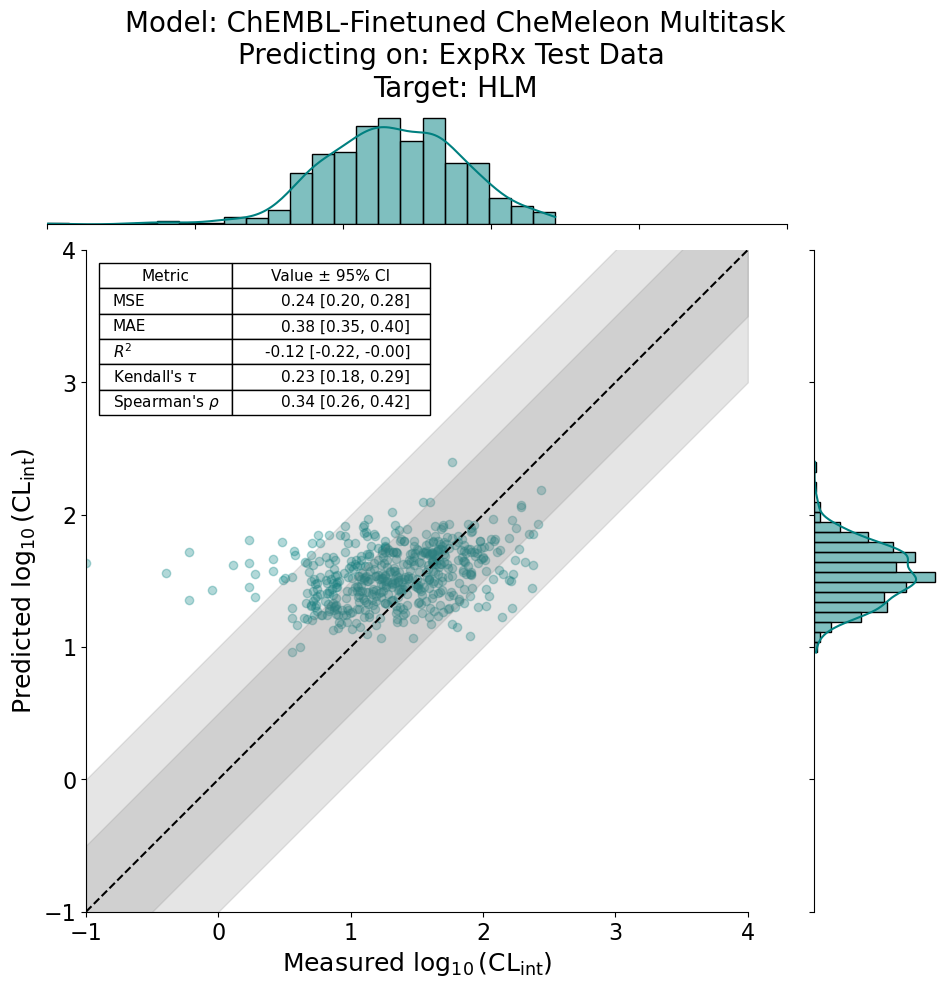

In [7]:
evaluator = RegressionMetrics()
data = RegressionMetrics.evaluate(
    evaluator,
    y_true=chembl_y_true,
    y_pred=chembl_y_preds,
    tag="CLint",
    target_label="Log10_CLint"
    )

stat_dict = RegressionMetrics.get_stat_dict(evaluator, "task_0")

RegressionPlots.regplot(
    y_true=chembl_y_true,
    y_pred=chembl_y_preds,
    xlabel=r"Measured $\log_{10}(\mathrm{CL}_{\mathrm{int}})$",
    ylabel=r"Predicted $\log_{10}(\mathrm{CL}_{\mathrm{int}})$",
    title="Model: ChEMBL-Finetuned CheMeleon Multitask\n"
    "Predicting on: ExpRx Test Data \n"
    "Target: HLM",
    stat_dict=stat_dict,
    pXC50=True,
    min_val=-1,
    max_val=4,
    fit_reg=False
)

Oof! The ChEMBL-only finetuned CheMeleon model isn't the greatest predicting on the ExpRx test data.

Now, let's take a look at the CheMeleon model finetuned on both ChEMBL and ExpRx train data:

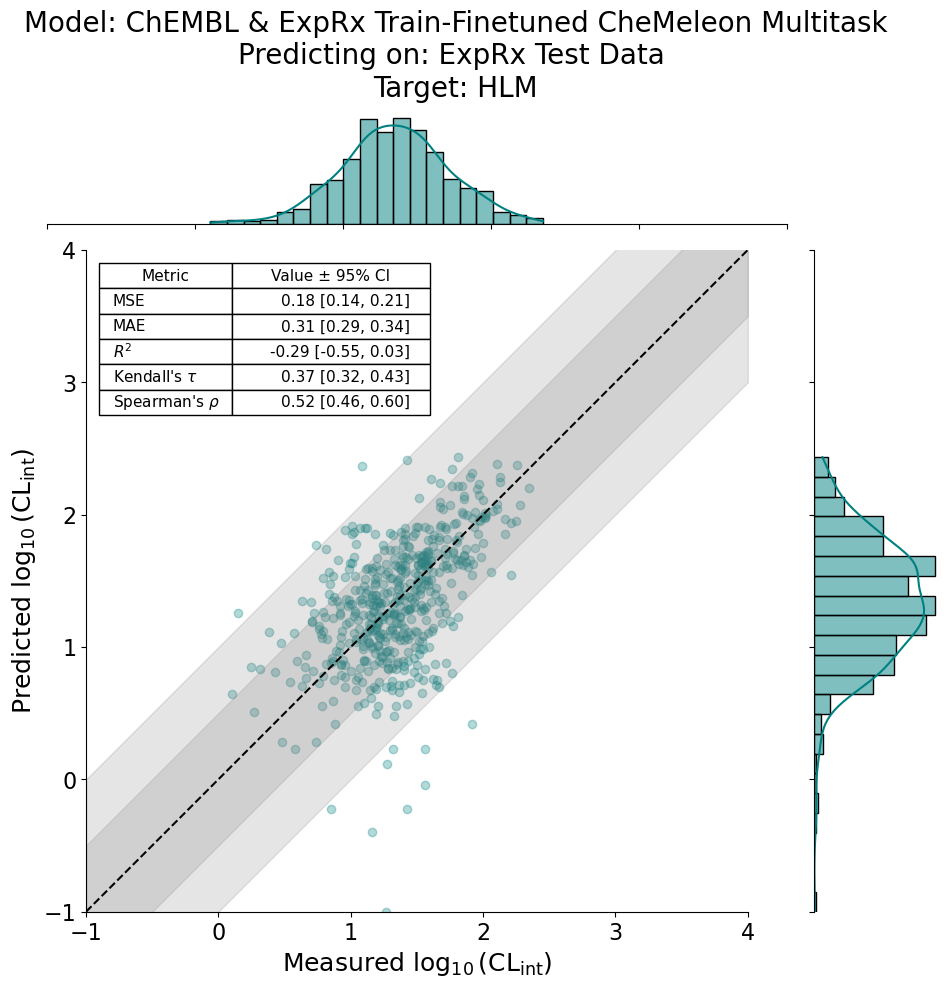

In [8]:
evaluator = RegressionMetrics()
data = RegressionMetrics.evaluate(
    evaluator,
    y_true=chembl_exprx_y_preds,
    y_pred=chembl_exprx_y_true,
    tag="CLint",
    target_label="Log10_CLint"
    )

stat_dict = RegressionMetrics.get_stat_dict(evaluator, "task_0")

RegressionPlots.regplot(
    y_true=chembl_exprx_y_preds,
    y_pred=chembl_exprx_y_true,
    xlabel=r"Measured $\log_{10}(\mathrm{CL}_{\mathrm{int}})$",
    ylabel=r"Predicted $\log_{10}(\mathrm{CL}_{\mathrm{int}})$",
    title="Model: ChEMBL & ExpRx Train-Finetuned CheMeleon Multitask\n"
    "Predicting on: ExpRx Test Data \n"
    "Target: HLM",
    stat_dict=stat_dict,
    pXC50=True,
    min_val=-1,
    max_val=4,
    fit_reg=False
)

Wow! That looks much better.

This demo showcases the potential gains of finetuning in model performance, even with just a small subset of data. Try it out with your own data!

## An alternative method of finetuning with ANVIL

In the above example, we showed finetuning by training two models on ChEMBL data and then ChEMBL+ExpRx train data. Alternatively, you can first finetune the model on ChEMBL data, then load the model checkpoint and finetune on the ExpRx data. This negates the need to concatenate a new dataset.

You can do this very easily in the ANVIL recipe `yaml` file, under the `model` section:

```yaml
  model:
    # Indicate model type
    # See openadmet.models.architecture
    type: ChemPropModel
    # load Pre-trained model
    serial_path: chemeleon_chembl/model.pth 
    param_path: chemeleon_chembl/model.json
    freeze_weights:
      message_passing: true
      batch_norm: false
    # Specify model parameters
    params:
      ffn_hidden_dim: 512
      ffn_hidden_num_layers: 3
      mpnn_lr: 1e-4
      ffn_lr: 1e-3
      mpnn_weight_decay: 0
      ffn_weight_decay: 1e-4
      dropout: 0.25
      batch_norm: False
      scheduler: plateau
      reduce_lr_patience: 5
      reduce_lr_factor: 0.5
      n_tasks: 3 # Number of tasks should match the number of target columns
      from_chemeleon: false # use the pre-trained Chemeleon model, will overwrite the model parameters except FFN

```

~ End of `06_Finetuning` ~